# Quantization-aware training of biePC (QAT biePC)

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/thebuckleylab/jpc/blob/main/examples/qat_biepc.ipynb)

This notebook demonstrates **quantization-aware training (QAT)** of the bidirectional incremental error-reparameterised PC variant ([biePC](./biepc.ipynb)), which combines the bidirectional PC architecture ([Oliviers et al., 2025](https://arxiv.org/abs/2505.23415)), the error reparameterisation of [ePC](https://arxiv.org/abs/2505.20137) ([Goemaere et al., 2025](https://arxiv.org/abs/2505.20137)), and the incremental interleaving of error and parameter updates from [iPC](https://arxiv.org/abs/2212.00720) ([Salvatori et al., 2024](https://arxiv.org/abs/2212.00720)). It is to [`qat_bepc.ipynb`](./qat_bepc.ipynb) what [`qat_iepc.ipynb`](./qat_iepc.ipynb) is to [`qat_epc.ipynb`](./qat_epc.ipynb): instead of relaxing the errors before a single joint weight update of the top-down and bottom-up networks, biePC interleaves a `jpc.update_bepc_params` call into every inference step.

The quantization recipe is identical to [`qat_bepc.ipynb`](./qat_bepc.ipynb): **fake quantization** with a **straight-through estimator (STE)**, applied to weights and input activations of every `Linear` layer. Master parameters stay in float32; only the forward matmul sees quantized values. Both the top-down generator and the bottom-up amortiser are built from `QuantLinear` layers, so every matmul in the bidirectional energy — forward errors, backward reconstructions, and the perturbed activities $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$ — is fake-quantized. What changes from the bePC variant is the training loop: an interleaved `update_bepc_params` call means each batch sees `depth - 1` parameter updates instead of one, amortizing gradient signal across the relaxation.

Two quantization modes are supported:
- **W4A8**: 4-bit weights, 8-bit activations (inference errors, inter-layer signals).
- **W4A4**: 4-bit weights, 4-bit activations.

and two number formats:
- **Posit** (primary): Posit\<4,2\> for weights and Posit\<8,2\> for activations, mirroring the `Posit4.jl` LUT-based reference and the `softposit` Python package for 8-bit.
- **FP** (ablation): FP4 `E2M1` (MXFP4-style) and FP8 `E4M3`.

In [ ]:
%%capture
!pip install torch==2.3.1
!pip install torchvision==0.18.1
!pip install matplotlib==3.0.0

In [1]:
import math
from typing import Optional

import jpc

import numpy as np
import jax
import jax.numpy as jnp
import jax.random as jr
import equinox as eqx
import equinox.nn as nn
import optax

import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

import warnings
warnings.simplefilter('ignore')

## Hyperparameters

Matching [`biepc.ipynb`](./biepc.ipynb) and [`qat_bepc.ipynb`](./qat_bepc.ipynb): a shallow joint generator/classifier where $x$ is the one-hot label (`INPUT_DIM=10`) and $y$ is the flattened image (`OUTPUT_DIM=784`).

In [2]:
SEED = 0

INPUT_DIM = 10
WIDTH = 256
DEPTH = 2
OUTPUT_DIM = 784
ACT_FN = "relu"

ERROR_LR = 5e-1
PARAM_LR = 1e-3
BATCH_SIZE = 64
TEST_EVERY = 50
N_TRAIN_ITERS = 300

## Quantization grids

Each format is defined by a sorted 1D array of its representable finite values. At forward time, a tensor is quantized by:

1. computing a per-tensor **absmax scale** so the largest magnitude maps to the largest representable level,
2. snapping every scaled element to the **nearest level**,
3. rescaling back.

Special encodings (NaR for posits, NaN for FP) are dropped from the grid — they should never appear in a well-scaled tensor and would break nearest-neighbour search.

In [3]:
def enumerate_posit(n: int, es: int) -> np.ndarray:
    """All finite values representable by Posit<n,es>, sorted, NaR excluded.

    Matches the Posit<4,es> tables in ``Posit4.jl`` (useed = 2**(2**es)).
    """
    useed = 2 ** (2 ** es)
    nar = 1 << (n - 1)
    mask = (1 << n) - 1
    out = set()
    for bits in range(1 << n):
        if bits == nar:
            continue
        if bits == 0:
            out.add(0.0); continue
        s = (bits >> (n - 1)) & 1
        mag = bits if s == 0 else ((~bits) + 1) & mask
        rb = mag & ((1 << (n - 1)) - 1)
        pos = n - 2
        r_sign = (rb >> pos) & 1
        m = 0
        while pos >= 0 and ((rb >> pos) & 1) == r_sign:
            m += 1; pos -= 1
        k = (m - 1) if r_sign == 1 else -m
        if pos >= 0:
            pos -= 1  # terminating bit
        exp_avail = min(es, pos + 1)
        if exp_avail > 0:
            e = (rb >> (pos - exp_avail + 1)) & ((1 << exp_avail) - 1)
            pos -= exp_avail
        else:
            e = 0
        fb = pos + 1
        f = ((rb & ((1 << fb) - 1)) / (1 << fb)) if fb > 0 else 0.0
        v = (useed ** k) * (2 ** e) * (1 + f)
        out.add(-v if s else v)
    return np.array(sorted(out), dtype=np.float32)


def enumerate_fp(ebits: int, mbits: int, bias: int, has_nan: bool = True) -> np.ndarray:
    """All finite values of an IEEE-style minifloat, sorted, NaN/Inf excluded.

    ``has_nan=True`` mirrors FP8 E4M3 (no Inf; NaN at Emax, mantissa=all-ones).
    ``has_nan=False`` mirrors MXFP4 E2M1, where every codepoint is a finite number.
    """
    total = 1 + ebits + mbits
    emax = (1 << ebits) - 1
    mmax = (1 << mbits) - 1
    out = set()
    for bits in range(1 << total):
        s = (bits >> (total - 1)) & 1
        e = (bits >> mbits) & emax
        m = bits & mmax
        if e == 0:
            v = (m / (1 << mbits)) * (2 ** (1 - bias))
        elif has_nan and e == emax and m == mmax:
            continue  # NaN slot
        else:
            v = (1 + m / (1 << mbits)) * (2 ** (e - bias))
        out.add(-v if s else v)
    return np.array(sorted(out), dtype=np.float32)


# Precomputed level grids. Kept as JAX arrays for fast nearest-neighbour search.
LEVELS = {
    "posit4_0":  jnp.asarray(enumerate_posit(4, 0)),
    "posit4_1":  jnp.asarray(enumerate_posit(4, 1)),
    "posit4_2":  jnp.asarray(enumerate_posit(4, 2)),
    "posit8_2":  jnp.asarray(enumerate_posit(8, 2)),
    "fp4_e2m1":  jnp.asarray(enumerate_fp(ebits=2, mbits=1, bias=1, has_nan=False)),
    "fp8_e4m3":  jnp.asarray(enumerate_fp(ebits=4, mbits=3, bias=7, has_nan=True)),
}

for name, lv in LEVELS.items():
    pos = lv[lv > 0]
    print(f"{name:10s}  {lv.size:3d} levels   "
          f"min|x|={float(pos.min()):.4g}   max|x|={float(pos.max()):.4g}")

posit4_0     15 levels   min|x|=0.25   max|x|=4
posit4_1     15 levels   min|x|=0.0625   max|x|=16
posit4_2     15 levels   min|x|=0.003906   max|x|=256
posit8_2    255 levels   min|x|=5.96e-08   max|x|=1.678e+07
fp4_e2m1     15 levels   min|x|=0.5   max|x|=6
fp8_e4m3    253 levels   min|x|=0.001953   max|x|=448


## Fake quantization and `QuantLinear`

`fake_quant` does per-tensor RMS scaling, nearest-level rounding, rescaling, and wraps the result in a **straight-through estimator** (`x + stop_gradient(x_q - x)`). We use RMS rather than absmax because posit precision peaks at $|x|=1$ — absmax scaling would squash typical values into the posit tails and waste most of the grid.

`QuantLinear` is a drop-in replacement for `eqx.nn.Linear` that quantizes its input activations with the chosen `a_format` and its weights with the chosen `w_format`. Because `QuantLinear` subclasses `eqx.nn.Linear`, it exposes a `.weight` attribute — matching what JPC's internals inspect when computing PC energies and gradients.

In [4]:
def fake_quant(x: jax.Array, levels: jax.Array) -> jax.Array:
    """Quantize ``x`` to the grid ``levels`` with RMS scaling + STE.

    - Per-tensor scale = RMS(x) so typical magnitudes map to |x|~1, where both
      posit and FP grids have their densest precision.
    - Nearest-neighbour rounding against the grid.
    - Straight-through gradient: ``grad(x_q) == grad(x)``.
    """
    scale = jnp.sqrt(jnp.mean(x * x) + 1e-12)
    x_scaled = x / scale
    diffs = jnp.abs(x_scaled[..., None] - levels)
    idx = jnp.argmin(diffs, axis=-1)
    x_q = levels[idx] * scale
    return x + jax.lax.stop_gradient(x_q - x)


class QuantLinear(nn.Linear):
    """``eqx.nn.Linear`` with fake-quantized weights and input activations."""

    w_format: str = eqx.field(static=True)
    a_format: str = eqx.field(static=True)

    def __init__(
        self,
        in_features: int,
        out_features: int,
        *,
        use_bias: bool = True,
        key,
        w_format: str,
        a_format: str,
    ):
        super().__init__(in_features, out_features, use_bias=use_bias, key=key)
        self.w_format = w_format
        self.a_format = a_format

    def __call__(self, x, *, key=None):
        x_q = fake_quant(x, LEVELS[self.a_format])
        W_q = fake_quant(self.weight, LEVELS[self.w_format])
        y = W_q @ x_q
        if self.bias is not None:
            y = y + self.bias
        return y


def make_quant_mlp(
    key,
    input_dim: int,
    width: int,
    depth: int,
    output_dim: int,
    act_fn: str,
    w_format: str,
    a_format: str,
    use_bias: bool = True,
):
    """Mirror of ``jpc.make_mlp`` that uses ``QuantLinear`` instead of ``nn.Linear``."""
    subkeys = jr.split(key, depth)
    act_lookup = {"relu": jax.nn.relu, "tanh": jnp.tanh, "gelu": jax.nn.gelu}
    layers = []
    for i in range(depth):
        act = nn.Identity() if i == 0 else nn.Lambda(act_lookup[act_fn])
        _in = input_dim if i == 0 else width
        _out = output_dim if (i + 1) == depth else width
        linear = QuantLinear(
            _in, _out,
            use_bias=use_bias,
            key=subkeys[i],
            w_format=w_format,
            a_format=a_format,
        )
        layers.append(nn.Sequential([act, linear]))
    return layers

### Sanity check

Round-trip a random tensor through each format to confirm the quantizer snaps to the grid and that the STE leaves gradients untouched.

In [5]:
_rng = jr.PRNGKey(0)
_x = jr.normal(_rng, (1024,))
for fmt in LEVELS:
    _xq = fake_quant(_x, LEVELS[fmt])
    _err = float(jnp.sqrt(jnp.mean((_xq - _x) ** 2)))
    print(f"{fmt:10s}  RMSE(x, fake_quant(x)) = {_err:.4f}")

# STE check: gradient of a quantized identity should be 1.
_g = jax.grad(lambda x: fake_quant(x, LEVELS["posit4_2"]).sum())(_x)
print(f"STE grad mean = {float(_g.mean()):.6f}   (expected 1.0)")

posit4_0    RMSE(x, fake_quant(x)) = 0.1300
posit4_1    RMSE(x, fake_quant(x)) = 0.1929
posit4_2    RMSE(x, fake_quant(x)) = 0.2657
posit8_2    RMSE(x, fake_quant(x)) = 0.0260
fp4_e2m1    RMSE(x, fake_quant(x)) = 0.1509
fp8_e4m3    RMSE(x, fake_quant(x)) = 0.0260
STE grad mean = 1.000000   (expected 1.0)


## Dataset

Standard MNIST loader, identical to [`biepc.ipynb`](./biepc.ipynb).

In [6]:
def get_mnist_loaders(batch_size):
    train_data = MNIST(train=True, normalise=True)
    test_data = MNIST(train=False, normalise=True)
    train_loader = DataLoader(
        dataset=train_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    test_loader = DataLoader(
        dataset=test_data,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )
    return train_loader, test_loader


class MNIST(datasets.MNIST):
    def __init__(self, train, normalise=True, save_dir="data"):
        if normalise:
            transform = transforms.Compose(
                [
                    transforms.ToTensor(),
                    transforms.Normalize(
                        mean=(0.1307,), std=(0.3081,)
                    )
                ]
            )
        else:
            transform = transforms.Compose([transforms.ToTensor()])
        super().__init__(save_dir, download=True, train=train, transform=transform)

    def __getitem__(self, index):
        img, label = super().__getitem__(index)
        return torch.flatten(img), one_hot(label)


def one_hot(labels, n_classes=10):
    return torch.eye(n_classes)[labels]


def plot_mnist_imgs(imgs, labels, n_imgs=10):
    plt.figure(figsize=(20, 2))
    for i in range(n_imgs):
        plt.subplot(1, n_imgs, i + 1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(imgs[i].reshape(28, 28), cmap=plt.cm.binary_r)
        plt.xlabel(jnp.argmax(labels, axis=1)[i])
    plt.show()

## Train and test

The training loop mirrors [`biepc.ipynb`](./biepc.ipynb): initialize zero errors, then at every one of `depth - 1` inference steps call `jpc.update_bepc_errors` followed immediately by `jpc.update_bepc_params` — no outer parameter update after the loop. As in [`qat_bepc.ipynb`](./qat_bepc.ipynb), the only structural change from the unquantized baseline is that both networks are built by `make_quant_mlp` rather than `jpc.make_mlp`, so every `W_q @ x_q` matmul inside the bidirectional error and parameter energies is fake-quantized on the forward pass while backprop uses the STE pass-through.

In [7]:
def evaluate(generator, amortiser, test_loader):
    amort_accs = 0.
    for _, (img_batch, label_batch) in enumerate(test_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_accs += jpc.compute_accuracy(label_batch, preds)

    img_preds = jpc.init_activities_with_ffwd(
        model=generator,
        input=label_batch
    )[-1]

    return (
        amort_accs / len(test_loader),
        label_batch,
        img_preds
    )


def train(
    seed,
    input_dim,
    width,
    depth,
    output_dim,
    act_fn,
    batch_size,
    error_lr,
    param_lr,
    test_every,
    n_train_iters,
    w_format: str,
    a_format: str,
    forward_energy_weight: float = 1.0,
    show_samples: bool = False,
):
    key = jax.random.PRNGKey(seed)
    gen_key, amort_key = jax.random.split(key, 2)

    # models (NOTE: input and output are inverted for the amortiser)
    generator = make_quant_mlp(
        gen_key,
        input_dim=input_dim,
        width=width,
        depth=depth,
        output_dim=output_dim,
        act_fn=act_fn,
        w_format=w_format,
        a_format=a_format,
        use_bias=True,
    )
    amortiser = make_quant_mlp(
        amort_key,
        input_dim=output_dim,
        width=width,
        depth=depth,
        output_dim=input_dim,
        act_fn=act_fn,
        w_format=w_format,
        a_format=a_format,
        use_bias=True,
    )[::-1]

    # optimisers
    error_optim = optax.sgd(error_lr)
    gen_optim = optax.adam(param_lr)
    amort_optim = optax.adam(param_lr)
    gen_opt_state = gen_optim.init(eqx.filter(generator, eqx.is_array))
    amort_opt_state = amort_optim.init(eqx.filter(amortiser, eqx.is_array))

    layer_sizes = [input_dim] + [width] * (depth - 1) + [output_dim]

    # data
    train_loader, test_loader = get_mnist_loaders(batch_size)

    for it, (img_batch, label_batch) in enumerate(train_loader):
        img_batch, label_batch = img_batch.numpy(), label_batch.numpy()

        # feedforward losses (for logging only)
        amort_preds = jpc.init_activities_with_ffwd(
            model=amortiser[::-1],
            input=img_batch
        )[-1]
        amort_loss = jpc.mse_loss(amort_preds, label_batch)

        gen_preds = jpc.init_activities_with_ffwd(
            model=generator,
            input=label_batch
        )[-1]
        gen_loss = jpc.mse_loss(gen_preds, img_batch)

        # biePC: initialise errors to zero and interleave inference with learning
        errors = jpc.init_epc_errors(
            layer_sizes=layer_sizes,
            batch_size=batch_size
        )
        error_opt_state = error_optim.init(errors)

        for _ in range(depth - 1):
            error_update_result = jpc.update_bepc_errors(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                optim=error_optim,
                opt_state=error_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            errors = error_update_result["errors"]
            error_opt_state = error_update_result["opt_state"]

            param_update_result = jpc.update_bepc_params(
                top_down_model=generator,
                bottom_up_model=amortiser,
                errors=errors,
                top_down_optim=gen_optim,
                bottom_up_optim=amort_optim,
                top_down_opt_state=gen_opt_state,
                bottom_up_opt_state=amort_opt_state,
                output=img_batch,
                input=label_batch,
                forward_energy_weight=forward_energy_weight
            )
            generator, amortiser = param_update_result["models"]
            gen_opt_state, amort_opt_state = param_update_result["opt_states"]

        if ((it + 1) % test_every) == 0:
            amort_acc, label_batch, img_preds = evaluate(
                generator, amortiser, test_loader
            )
            print(
                f"[{w_format}/{a_format}] iter {it + 1}, "
                f"gen loss={float(gen_loss):.4f}, "
                f"amort loss={float(amort_loss):.4f}, "
                f"amort test acc={float(amort_acc):.4f}"
            )

            if (it + 1) >= n_train_iters:
                break

    if show_samples:
        plot_mnist_imgs(img_preds, label_batch)

    return generator, amortiser

## Run — W4A8 posits (primary target)

4-bit **Posit\<4,2\>** weights and 8-bit **Posit\<8,2\>** activations, applied to both the generator and the amortiser. The Posit\<4,2\> grid is the same as the one tabulated in the accompanying `Posit4.jl` reference. We show generated samples from the quantized generator at the end of training.

100.0%
100.0%
100.0%
100.0%


[posit4_2/posit8_2] iter 50, gen loss=261.5654, amort loss=0.3132, amort test acc=74.3490
[posit4_2/posit8_2] iter 100, gen loss=247.0568, amort loss=0.2462, amort test acc=79.7075
[posit4_2/posit8_2] iter 150, gen loss=207.3003, amort loss=0.2530, amort test acc=80.7292
[posit4_2/posit8_2] iter 200, gen loss=232.9061, amort loss=0.3359, amort test acc=77.6743
[posit4_2/posit8_2] iter 250, gen loss=207.5130, amort loss=0.2427, amort test acc=80.9095
[posit4_2/posit8_2] iter 300, gen loss=217.8907, amort loss=0.2125, amort test acc=81.2600


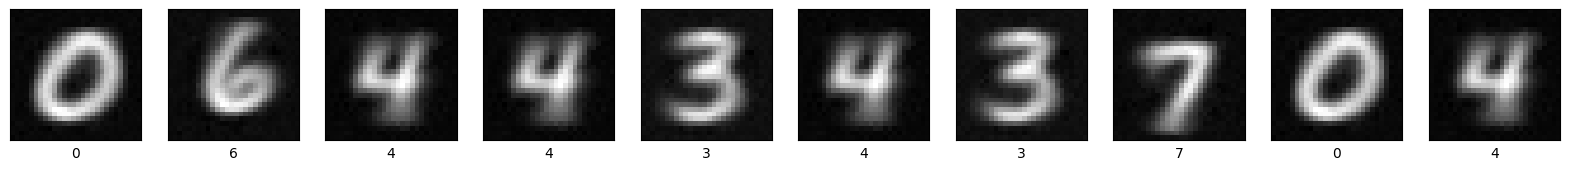

In [8]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit8_2",
    show_samples=True,
)

### Classification-biased run

As with bPC, bePC, and biePC, downweighting the forward energy (equivalently upweighting the backward / classification energy) biases the joint objective toward classification. We reproduce this knob under the same W4A8 posit configuration with $\alpha_f = 10^{-3}$.

[posit4_2/posit8_2] iter 50, gen loss=260.8970, amort loss=0.2888, amort test acc=74.0885
[posit4_2/posit8_2] iter 100, gen loss=244.0203, amort loss=0.2371, amort test acc=77.0333
[posit4_2/posit8_2] iter 150, gen loss=243.6815, amort loss=0.2987, amort test acc=77.9848
[posit4_2/posit8_2] iter 200, gen loss=236.4624, amort loss=0.2717, amort test acc=79.0365
[posit4_2/posit8_2] iter 250, gen loss=236.2602, amort loss=0.2998, amort test acc=78.9563
[posit4_2/posit8_2] iter 300, gen loss=234.9142, amort loss=0.2767, amort test acc=74.0284


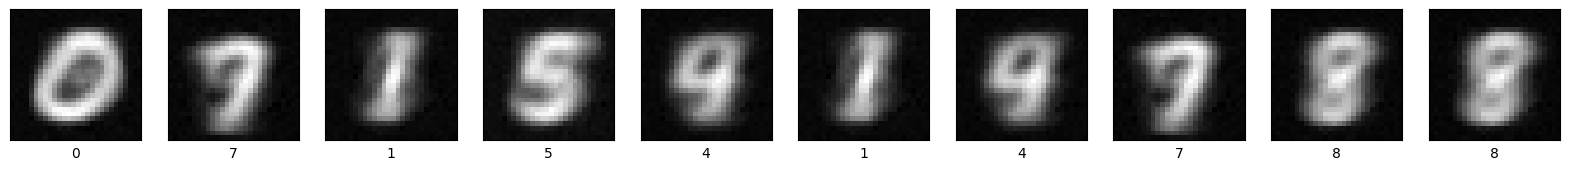

In [9]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit8_2",
    forward_energy_weight=1e-3,
    show_samples=True,
)

## Run — W4A4 posits

Pushing activations down to Posit\<4,2\> as well. This is the most aggressive configuration — expect a larger accuracy gap vs. the unquantized biePC baseline in [`biepc.ipynb`](./biepc.ipynb), and noticeably worse generative samples from the top-down network.

[posit4_2/posit4_2] iter 50, gen loss=272.9421, amort loss=0.3546, amort test acc=60.3666
[posit4_2/posit4_2] iter 100, gen loss=236.5790, amort loss=0.2583, amort test acc=77.3237
[posit4_2/posit4_2] iter 150, gen loss=228.4690, amort loss=0.2912, amort test acc=78.6558
[posit4_2/posit4_2] iter 200, gen loss=222.1824, amort loss=0.2670, amort test acc=79.2869
[posit4_2/posit4_2] iter 250, gen loss=227.6884, amort loss=0.2378, amort test acc=78.6558
[posit4_2/posit4_2] iter 300, gen loss=223.6086, amort loss=0.2753, amort test acc=78.7961


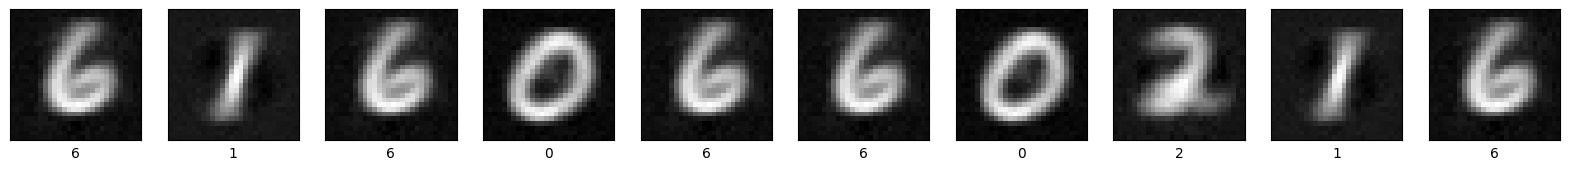

In [10]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="posit4_2",
    a_format="posit4_2",
    show_samples=True,
)

## Ablation — FP4/FP8

Swapping in MXFP4-style `E2M1` weights and `E4M3` FP8 activations. Same training recipe, same number of mantissa+exponent bits per value; only the distribution of representable magnitudes differs. Running both W4A8 and W4A4 variants for direct comparison with the posit rows above.

[fp4_e2m1/fp8_e4m3] iter 50, gen loss=254.5974, amort loss=0.2360, amort test acc=76.8530
[fp4_e2m1/fp8_e4m3] iter 100, gen loss=221.7145, amort loss=0.2619, amort test acc=80.6290
[fp4_e2m1/fp8_e4m3] iter 150, gen loss=200.0770, amort loss=0.1883, amort test acc=80.6691
[fp4_e2m1/fp8_e4m3] iter 200, gen loss=234.1755, amort loss=0.2651, amort test acc=81.5405
[fp4_e2m1/fp8_e4m3] iter 250, gen loss=232.2617, amort loss=0.2391, amort test acc=82.3417
[fp4_e2m1/fp8_e4m3] iter 300, gen loss=222.7025, amort loss=0.2187, amort test acc=83.0629


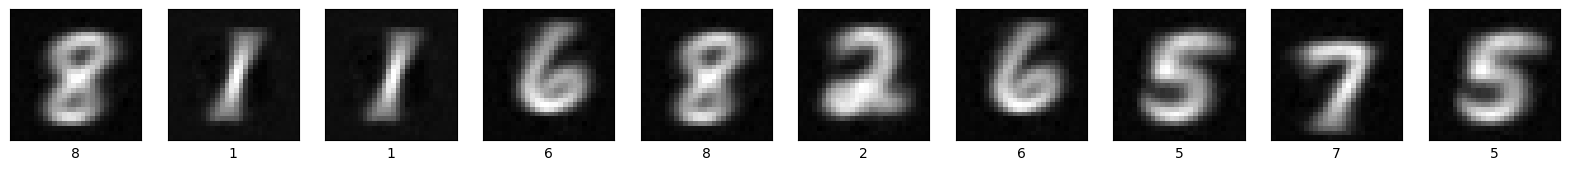

[fp4_e2m1/fp4_e2m1] iter 50, gen loss=249.3294, amort loss=0.3091, amort test acc=73.8882
[fp4_e2m1/fp4_e2m1] iter 100, gen loss=228.1390, amort loss=0.2566, amort test acc=81.2800
[fp4_e2m1/fp4_e2m1] iter 150, gen loss=226.6226, amort loss=0.1984, amort test acc=82.5821
[fp4_e2m1/fp4_e2m1] iter 200, gen loss=220.2222, amort loss=0.2361, amort test acc=79.3770
[fp4_e2m1/fp4_e2m1] iter 250, gen loss=210.0795, amort loss=0.1912, amort test acc=82.5821
[fp4_e2m1/fp4_e2m1] iter 300, gen loss=231.4710, amort loss=0.2410, amort test acc=81.5004


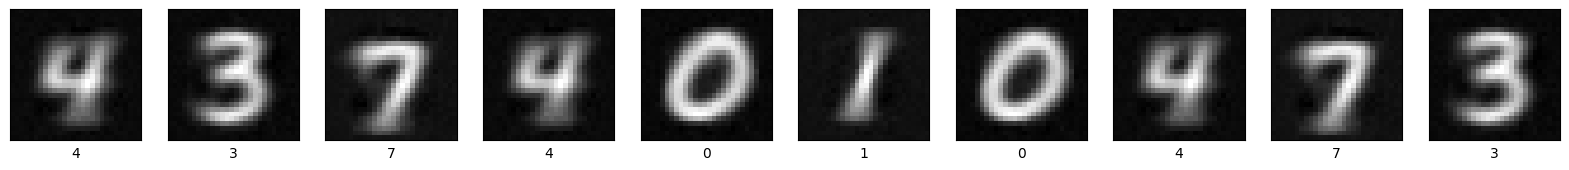

In [11]:
_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="fp4_e2m1",
    a_format="fp8_e4m3",
    show_samples=True,
)

_ = train(
    seed=SEED,
    input_dim=INPUT_DIM,
    width=WIDTH,
    depth=DEPTH,
    output_dim=OUTPUT_DIM,
    act_fn=ACT_FN,
    batch_size=BATCH_SIZE,
    error_lr=ERROR_LR,
    param_lr=PARAM_LR,
    test_every=TEST_EVERY,
    n_train_iters=N_TRAIN_ITERS,
    w_format="fp4_e2m1",
    a_format="fp4_e2m1",
    show_samples=True,
)

## Ablation — Posit ES sweep

Same sweep as in [`qat_bepc.ipynb`](./qat_bepc.ipynb) and [`qat_iepc.ipynb`](./qat_iepc.ipynb): vary Posit\<4,`ES`\> weights over `ES ∈ {0, 1}` and run both W4A8 (Posit\<8,2\> activations held fixed) and W4A4 (same 4-bit format on both sides) variants for each `ES`. The bidirectional setting is a useful stress test because the amortiser's outputs (class logits under RMS scaling) span a different magnitude distribution than the generator's outputs (pixel-space reconstructions), so the `ES` choice trades dynamic range against density in the $|x|\approx 1$ band for *both* networks simultaneously — and the interleaved parameter updates mean those distributions shift while the errors are still relaxing.

Grid comparison (positive side, 7 non-zero levels each):

| Format | min\|x\| | max\|x\| | useed |
| :-- | --: | --: | --: |
| Posit\<4,0\> | 1/4 | 4 | 2 |
| Posit\<4,1\> | 1/16 | 16 | 4 |
| Posit\<4,2\> | 1/256 | 256 | 16 |

[posit4_0/posit8_2] iter 50, gen loss=242.7317, amort loss=0.2435, amort test acc=75.5108
[posit4_0/posit8_2] iter 100, gen loss=223.0772, amort loss=0.2361, amort test acc=81.6406
[posit4_0/posit8_2] iter 150, gen loss=221.2707, amort loss=0.2469, amort test acc=81.1298
[posit4_0/posit8_2] iter 200, gen loss=217.2769, amort loss=0.2239, amort test acc=83.4135
[posit4_0/posit8_2] iter 250, gen loss=218.9236, amort loss=0.2419, amort test acc=82.5521
[posit4_0/posit8_2] iter 300, gen loss=225.0988, amort loss=0.2195, amort test acc=84.2949


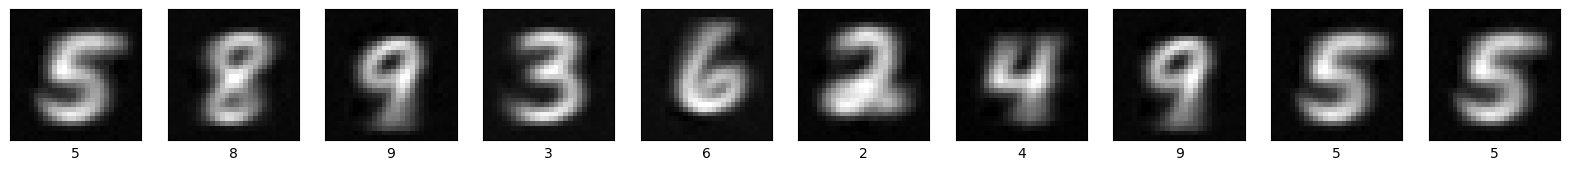

[posit4_0/posit4_0] iter 50, gen loss=255.6943, amort loss=0.2602, amort test acc=76.4323
[posit4_0/posit4_0] iter 100, gen loss=223.9809, amort loss=0.2432, amort test acc=81.3401
[posit4_0/posit4_0] iter 150, gen loss=225.8831, amort loss=0.2284, amort test acc=82.7825
[posit4_0/posit4_0] iter 200, gen loss=215.4296, amort loss=0.2273, amort test acc=81.3201
[posit4_0/posit4_0] iter 250, gen loss=226.5737, amort loss=0.2451, amort test acc=82.4920
[posit4_0/posit4_0] iter 300, gen loss=232.4204, amort loss=0.1950, amort test acc=83.5136


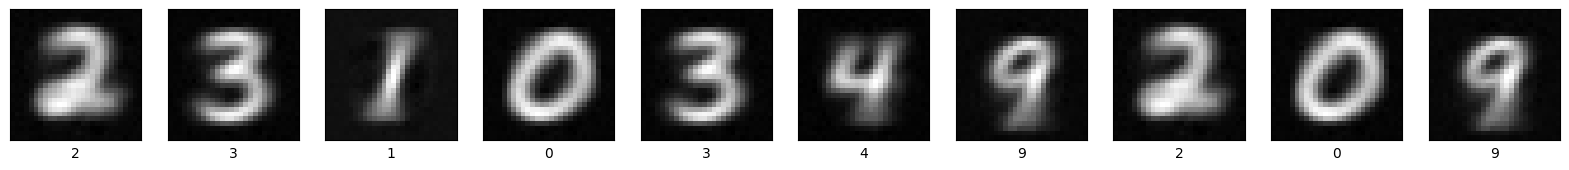

[posit4_1/posit8_2] iter 50, gen loss=249.7208, amort loss=0.2846, amort test acc=76.0917
[posit4_1/posit8_2] iter 100, gen loss=244.7289, amort loss=0.2317, amort test acc=81.6106
[posit4_1/posit8_2] iter 150, gen loss=225.8209, amort loss=0.2403, amort test acc=81.0196
[posit4_1/posit8_2] iter 200, gen loss=223.4415, amort loss=0.2375, amort test acc=83.4435
[posit4_1/posit8_2] iter 250, gen loss=222.6252, amort loss=0.2323, amort test acc=83.5437
[posit4_1/posit8_2] iter 300, gen loss=224.1968, amort loss=0.2542, amort test acc=82.4018


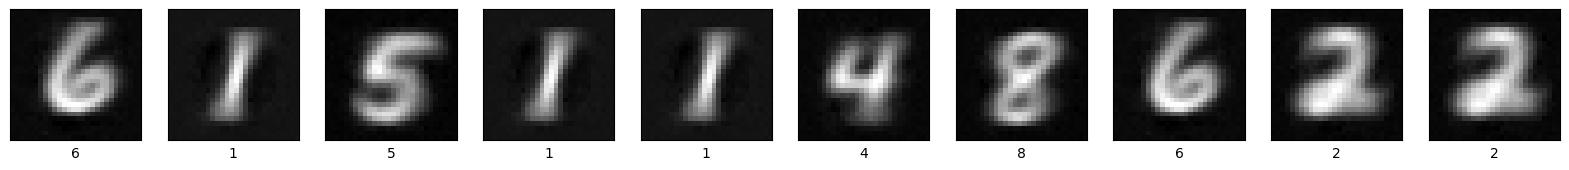

[posit4_1/posit4_1] iter 50, gen loss=240.7414, amort loss=0.2488, amort test acc=77.0933
[posit4_1/posit4_1] iter 100, gen loss=245.4180, amort loss=0.2436, amort test acc=80.2684
[posit4_1/posit4_1] iter 150, gen loss=230.5697, amort loss=0.2704, amort test acc=81.5905
[posit4_1/posit4_1] iter 200, gen loss=209.3301, amort loss=0.1786, amort test acc=82.0012
[posit4_1/posit4_1] iter 250, gen loss=213.7819, amort loss=0.2498, amort test acc=81.2700
[posit4_1/posit4_1] iter 300, gen loss=215.0358, amort loss=0.1934, amort test acc=82.2416


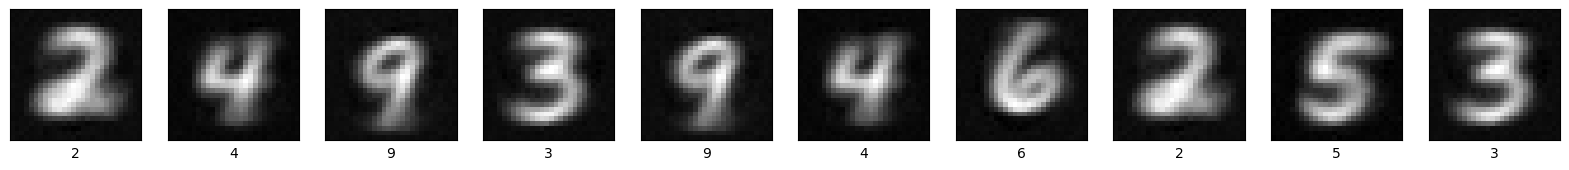

In [12]:
for es in (0, 1):
    w_fmt = f"posit4_{es}"

    # W4A8 variant: 4-bit posit weights, Posit<8,2> activations.
    _ = train(
        seed=SEED,
        input_dim=INPUT_DIM,
        width=WIDTH,
        depth=DEPTH,
        output_dim=OUTPUT_DIM,
        act_fn=ACT_FN,
        batch_size=BATCH_SIZE,
        error_lr=ERROR_LR,
        param_lr=PARAM_LR,
        test_every=TEST_EVERY,
        n_train_iters=N_TRAIN_ITERS,
        w_format=w_fmt,
        a_format="posit8_2",
        show_samples=True,
    )

    # W4A4 variant: same 4-bit posit for weights and activations.
    _ = train(
        seed=SEED,
        input_dim=INPUT_DIM,
        width=WIDTH,
        depth=DEPTH,
        output_dim=OUTPUT_DIM,
        act_fn=ACT_FN,
        batch_size=BATCH_SIZE,
        error_lr=ERROR_LR,
        param_lr=PARAM_LR,
        test_every=TEST_EVERY,
        n_train_iters=N_TRAIN_ITERS,
        w_format=w_fmt,
        a_format=w_fmt,
        show_samples=True,
    )

## Notes and extensions

- **biePC vs. bePC under QAT.** The STE means every JPC update function sees the quantizer as the identity, so `update_bepc_errors` and `update_bepc_params` are algorithm-agnostic and drop in unchanged. The only functional difference from [`qat_bepc.ipynb`](./qat_bepc.ipynb) is the training loop: biePC calls `update_bepc_params` once per inference step, amortizing `depth - 1` parameter updates per batch instead of one. With 4-bit weights this can be a mixed blessing — more frequent updates give more gradient signal but also inject more per-step quantization noise into the relaxation, and the bidirectional energy couples that noise across both networks.
- **biePC vs. iePC under QAT.** Compared with [`qat_iepc.ipynb`](./qat_iepc.ipynb), the loop structure is the same (interleaved error/parameter updates) but every bePC energy term now involves two fake-quantized networks. Asymmetric quantization between the generator and amortiser is a natural next experiment — swap the `w_format`/`a_format` arguments on each `make_quant_mlp` call.
- **What "QAT" means here.** Master weights of both the generator and amortiser stay in float32; only the forward pass matmuls and the activations that feed the next layer see quantized values. The STE means the bePC error/parameter gradients are computed as if the quantizer were the identity, so every JPC update function works unchanged.
- **Symmetric quantization of both networks.** We use the same `(w_format, a_format)` pair for the generator and amortiser. The bePC backward energy $\|\tilde{z}_\ell - g_{\ell+1}(\tilde{z}_{\ell+1})\|^2$ couples the two networks through the perturbed activities $\tilde{z}_\ell = f_\ell(\tilde{z}_{\ell-1}) + \epsilon_\ell$, and the interleaved parameter updates further tie their learning trajectories together.
- **Scaling.** Per-tensor RMS scaling is used for both weights and activations. For weights that is static per forward call; for activations it is dynamic (computed from the current batch). A common next step is per-output-channel weight scales.
- **Posit\<8,2\> vs. softposit.** For self-containedness the Posit\<8,2\> grid here is generated by the same pure-Python decoder used for Posit\<4,2\> — cross-check against `softposit.posit8(...)` if you have it installed; every one of the 255 finite values should match.